<a href="https://colab.research.google.com/github/Zions86/Zions86/blob/main/House_Price_Prediction_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# House Price Prediction

# problem Statement
The real estate industry often needs accurate estimation of property prices based on various house characteristics. In this task, the goal is to build a Machine Learning regression model that predicts the price of a house using features such as house size, number of bedrooms, number of bathrooms, lot size, garage size, neighborhood quality, and the year the house was built. Students are required to analyze the dataset, perform data preprocessing, apply feature engineering techniques, train multiple regression models, and evaluate their performance to identify the best model for predicting house prices.

# Objective
The objective of this task is to:


*   Understand and explore the housing dataset.
*   Perform data preprocessing including handling missing values, duplicates, and outliers.


* Conduct Exploratory Data Analysis (EDA) to identify patterns and relationships in the data.
*  Apply encoding, log transformation, and feature scaling where necessary.


*  Train multiple regression algorithms to predict house prices.
*   Evaluate and compare model performance using appropriate evaluation metrics.








# 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor

# Evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 2. Load the Dataset


In [2]:
df = pd.read_csv('house_price.csv')
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.599637,0,5,2.623829e+05
1,4272,3,3,2016,4.753014,1,6,9.852609e+05
2,3592,1,2,2016,3.634823,0,9,7.779774e+05
3,966,1,2,1977,2.730667,1,8,2.296989e+05
4,4926,2,1,1993,4.699073,0,8,1.041741e+06


# 3. Check Dataset

In [3]:
print(df.shape)
print(df.info())
print(df.describe())

(1000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Square_Footage        1000 non-null   int64  
 1   Num_Bedrooms          1000 non-null   int64  
 2   Num_Bathrooms         1000 non-null   int64  
 3   Year_Built            1000 non-null   int64  
 4   Lot_Size              1000 non-null   float64
 5   Garage_Size           1000 non-null   int64  
 6   Neighborhood_Quality  1000 non-null   int64  
 7   House_Price           1000 non-null   float64
dtypes: float64(2), int64(6)
memory usage: 62.6 KB
None
       Square_Footage  Num_Bedrooms  Num_Bathrooms   Year_Built     Lot_Size  \
count     1000.000000   1000.000000    1000.000000  1000.000000  1000.000000   
mean      2815.422000      2.990000       1.973000  1986.550000     2.778087   
std       1255.514921      1.427564       0.820332    20.632916     1.297903   

#4. Handle Missing Values

In [4]:
print(df.isnull().sum())

# Fill numeric with median
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].median(), inplace=True)

# Fill categorical with mode
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

Square_Footage          0
Num_Bedrooms            0
Num_Bathrooms           0
Year_Built              0
Lot_Size                0
Garage_Size             0
Neighborhood_Quality    0
House_Price             0
dtype: int64


/tmp/ipykernel_685/890375547.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


# 5. Remove Duplicate Records

In [5]:
df.drop_duplicates(inplace=True)

# 6. Perform Univariate Analysis

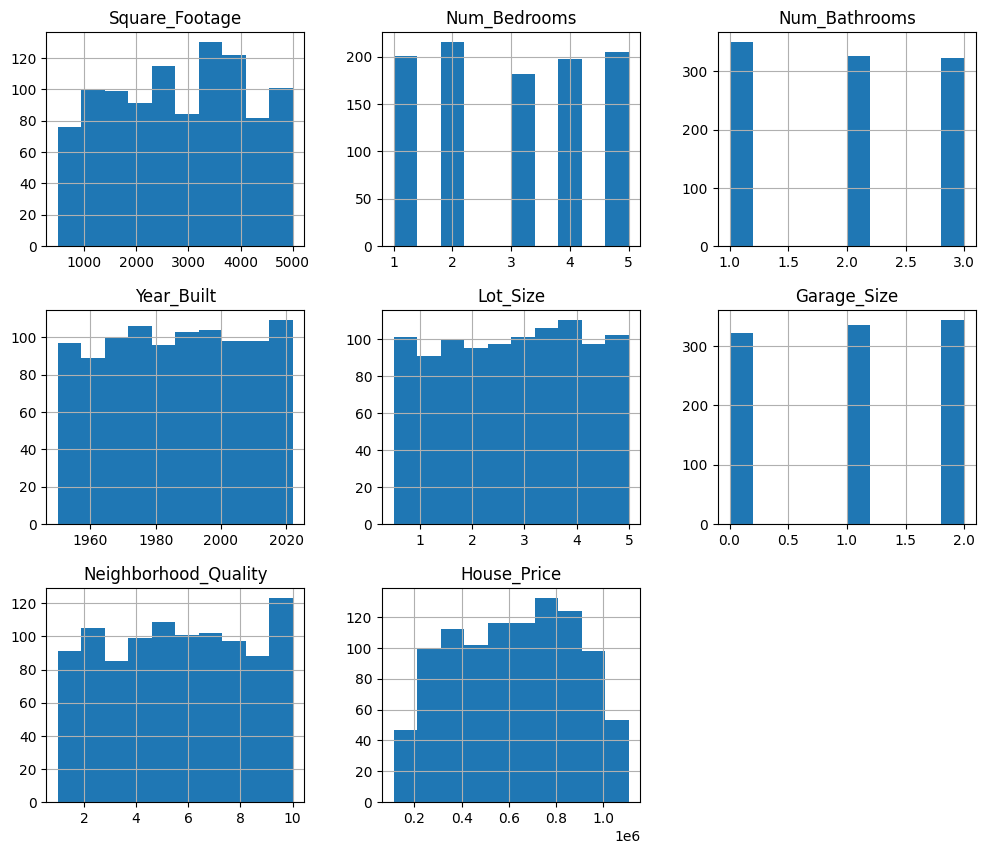

In [6]:
df.hist(figsize=(12,10))
plt.show()

# Count plot (if categorical exists)
for col in df.select_dtypes(include='object'):
    sns.countplot(x=df[col])
    plt.xticks(rotation=45)
    plt.show()

# 7. Perform Bivariate Analysis

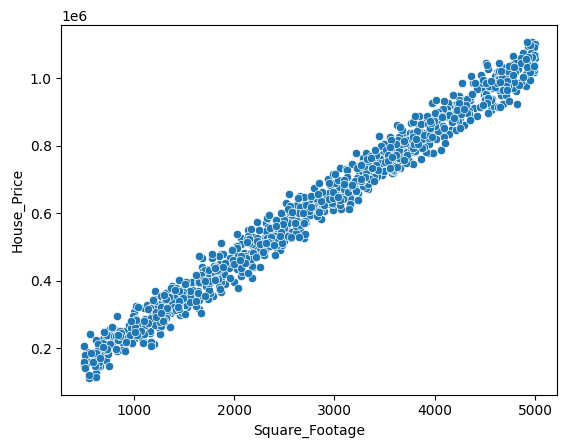

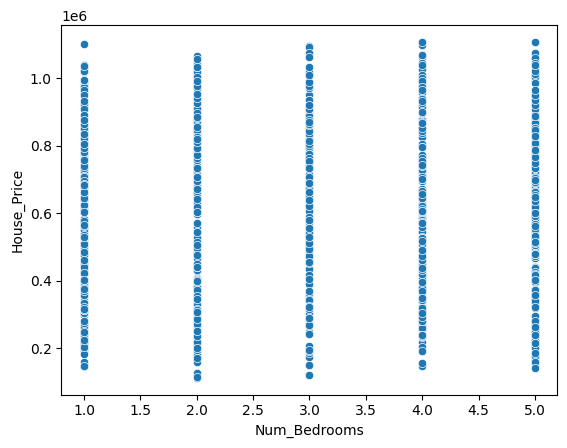

In [8]:
# Scatter plot example
sns.scatterplot(x='Square_Footage', y='House_Price', data=df)
plt.show()

sns.scatterplot(x='Num_Bedrooms', y='House_Price', data=df)
plt.show()

#8. Generate Correlation Heatmap

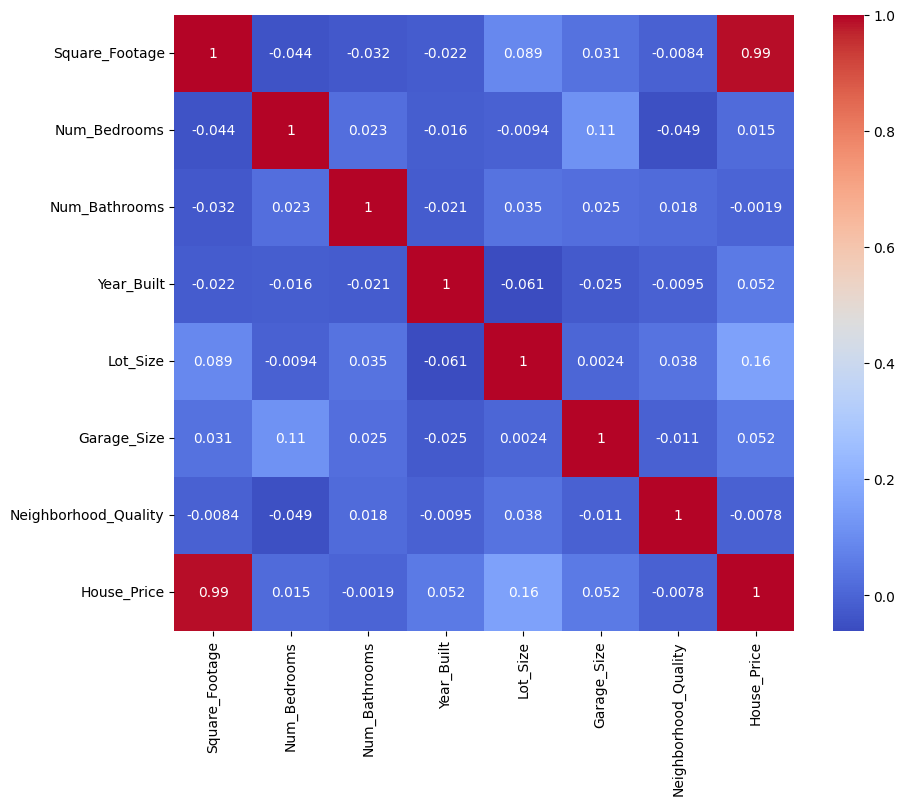

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

#9. Handle Outliers

In [10]:
# Using IQR method
for col in df.select_dtypes(include=np.number):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

# 10. Encoding (Categorical)

In [11]:
le = LabelEncoder()

for col in df.select_dtypes(include='object'):
    df[col] = le.fit_transform(df[col])

# 11. Log Transformation

In [13]:
df['House_Price'] = np.log1p(df['House_Price'])   # log transform target

#12. Features & Target

In [14]:
X = df.drop('House_Price', axis=1)
y = df['House_Price']

# 13. Train-Test Split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

#14. Feature Scaling

In [16]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#15. Train Models

# Linear Regression

In [17]:
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

# KNN Regression

In [18]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

# 16. Evaluation Function

In [19]:
def evaluate(y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100
    r2 = r2_score(y_test, y_pred)

    n = len(y_test)
    p = X_test.shape[1]
    adj_r2 = 1 - (1 - r2)*(n - 1)/(n - p - 1)

    return mae, mse, rmse, mape, r2, adj_r2

# Results

 Linear Regression


In [20]:
results_lr = evaluate(y_test, y_pred_lr)
print("Linear Regression:", results_lr)

Linear Regression: (0.09078250861533381, 0.012923008118806444, np.float64(0.11367940938800854), np.float64(0.6959836658331121), 0.9462496095496568, 0.9442899598978214)


# Results
KNN Regression

In [21]:
results_knn = evaluate(y_test, y_pred_knn)
print("KNN Regression:", results_knn)

KNN Regression: (0.13352426424801353, 0.03275222800192383, np.float64(0.18097576633882181), np.float64(1.0316050644496357), 0.8637743606567768, 0.8588078008890552)
